Week 4 Project 3

**Overlap between the ChIPseq results and original RNAseq data**  
Replication of Figure 2F:

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from matplotlib_venn import venn2

In [3]:
sns.set(style="whitegrid", context="talk")

rna_file = "rnaseq_results.txt"
gtf_file = "/projectnb/bf528/materials/project-3-chipseq/refs/gencode.v45.primary_assembly.annotation.gtf"
peaks_bed = "/projectnb/bf528/students/shrjain/project-3-shriyajain22/results/repr_cleaned_peaks.bed"   

In [4]:
rna = pd.read_csv(rna_file, sep="\t")

print("RNA columns:", rna.columns)

rna = rna.rename(columns={
    "genename": "gene_symbol",
    "log2FoldChange": "log2FC"
})

rna = rna[["gene_symbol", "log2FC", "padj"]].dropna(subset=["gene_symbol"])
print("RNA table shape:", rna.shape)
print(rna.head())

RNA columns: Index(['genename', 'transcript', 'log2FoldChange', 'padj'], dtype='object')
RNA table shape: (15434, 3)
  gene_symbol    log2FC      padj
0       OARD1  0.186841  0.545806
1     WBSCR22  0.037881  0.907305
2        PIGZ  0.122346  0.841445
3       PRDX5  0.250313  0.118073
4       PEX16 -0.300675  0.183572


In [5]:
gene_rows = []

with open(gtf_file, "r") as f:
    for line in f:
        if line.startswith("#"):
            continue
        fields = line.strip().split("\t")
        if len(fields) < 9:
            continue

        feature_type = fields[2]
        if feature_type != "gene":
            continue

        chrom = fields[0]
        start = int(fields[3])
        end   = int(fields[4])
        info  = fields[8]

        if 'gene_name "' not in info:
            continue
        gene_name = info.split('gene_name "')[1].split('"')[0]

        gene_rows.append((chrom, start, end, gene_name))

genes = pd.DataFrame(gene_rows, columns=["chrom", "start", "end", "gene_symbol"])
print("Gene coord table:", genes.shape)
print(genes.head())

Gene coord table: (63241, 4)
  chrom  start    end  gene_symbol
0  chr1  11869  14409      DDX11L2
1  chr1  12010  13670      DDX11L1
2  chr1  14696  24886       WASH7P
3  chr1  17369  17436    MIR6859-1
4  chr1  29554  31109  MIR1302-2HG


In [6]:
rna_annot = rna.merge(genes, on="gene_symbol", how="inner")

print("Annotated RNA rows:", rna_annot.shape)
print(rna_annot.head())

Annotated RNA rows: (14045, 6)
  gene_symbol    log2FC      padj  chrom      start        end
0       OARD1  0.186841  0.545806   chr6   41033627   41097787
1        PIGZ  0.122346  0.841445   chr3  196946356  196969060
2       PRDX5  0.250313  0.118073  chr11   64318121   64321811
3       PEX16 -0.300675  0.183572  chr11   45909663   45918812
4     SLC35G2  0.397400       NaN   chr3  136818647  136855888


In [7]:
up = rna_annot[(rna_annot["padj"] <= 0.01) & (rna_annot["log2FC"] > 1)]
down = rna_annot[(rna_annot["padj"] <= 0.01) & (rna_annot["log2FC"] < -1)]

print("Up-regulated genes:", up.shape[0])
print("Down-regulated genes:", down.shape[0])

Up-regulated genes: 594
Down-regulated genes: 430


In [8]:
rna_sig = pd.concat([up, down], ignore_index=True).copy()

# For simplicity, treat TSS = gene start
rna_sig["TSS"] = rna_sig["start"]

rna_sig["TSS_win_start"]  = rna_sig["TSS"] - 5000
rna_sig["TSS_win_end"]    = rna_sig["TSS"] + 5000
rna_sig["body_win_start"] = rna_sig["start"] - 20000
rna_sig["body_win_end"]   = rna_sig["end"]   + 20000

print("Significant DEGs with windows:", rna_sig.shape)

Significant DEGs with windows: (1024, 11)


In [9]:
# Assuming BED has at least: chrom, start, end
peaks = pd.read_csv(
    peaks_bed,
    sep="\t",
    header=None,
    usecols=[0, 1, 2],
    names=["chrom", "start", "end"]
)

print("Peaks table:", peaks.shape)
print(peaks.head())

Peaks table: (5000, 3)
   chrom      start        end
0  chr20   47319841   47320056
1  chr20   57264336   57264529
2   chr1  205211624  205211835
3  chr16   11915970   11916193
4   chr5  178078277  178078500


In [10]:
bound_genes = set()

# Iterate by chromosome to avoid crossing between chromosomes
for chrom, df_chr in rna_sig.groupby("chrom"):
    peaks_chr = peaks[peaks["chrom"] == chrom]
    if peaks_chr.empty:
        continue

    # For each DEG on this chromosome, check overlap
    for _, row in df_chr.iterrows():
        tss_start, tss_end   = row["TSS_win_start"], row["TSS_win_end"]
        body_start, body_end = row["body_win_start"], row["body_win_end"]

        # Peaks overlapping TSS window
        tss_overlap = (peaks_chr["start"] <= tss_end) & (peaks_chr["end"] >= tss_start)
        # Peaks overlapping gene body window
        body_overlap = (peaks_chr["start"] <= body_end) & (peaks_chr["end"] >= body_start)

        if tss_overlap.any() or body_overlap.any():
            bound_genes.add(row["gene_symbol"])

print("Number of DEGs with nearby RUNX1 peaks:", len(bound_genes))

Number of DEGs with nearby RUNX1 peaks: 322


In [11]:
def make_class_table(df, label):
    return pd.DataFrame({
        "gene_symbol": df["gene_symbol"],
        "direction": label,
        "bound": df["gene_symbol"].apply(
            lambda g: "Bound" if g in bound_genes else "Not bound"
        )
    })

plot_df = pd.concat([
    make_class_table(up, "Up"),
    make_class_table(down, "Down")
], ignore_index=True)

summary = (
    plot_df
    .groupby(["direction", "bound"])
    .size()
    .reset_index(name="count")
)

summary["percent"] = summary.groupby("direction")["count"].transform(
    lambda x: 100 * x / x.sum()
)

print(summary)

  direction      bound  count    percent
0      Down      Bound    153  35.581395
1      Down  Not bound    277  64.418605
2        Up      Bound    171  28.787879
3        Up  Not bound    423  71.212121


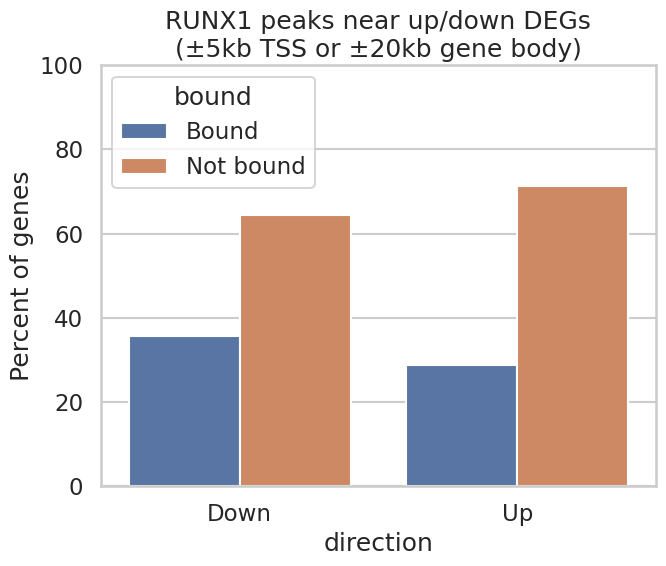

In [12]:
plt.figure(figsize=(7, 6))
sns.barplot(
    data=summary,
    x="direction",
    y="percent",
    hue="bound",
)
plt.ylabel("Percent of genes")
plt.title("RUNX1 peaks near up/down DEGs\n(±5kb TSS or ±20kb gene body)")
plt.ylim(0, 100)
plt.tight_layout()
plt.show()

**Comparing key findings to the original paper**  
Table, correlation plot and venn diagram:

Table:

In [32]:
import pandas as pd
import re

# Paths to your files
files = {
    "IP_rep1": "/projectnb/bf528/students/shrjain/project-3-shriyajain22/results/samtools_flagstat/IP_rep1_flagstat.txt",
    "IP_rep2": "/projectnb/bf528/students/shrjain/project-3-shriyajain22/results/samtools_flagstat/IP_rep2_flagstat.txt",
    "INPUT_rep1": "/projectnb/bf528/students/shrjain/project-3-shriyajain22/results/samtools_flagstat/INPUT_rep1_flagstat.txt",
    "INPUT_rep2": "/projectnb/bf528/students/shrjain/project-3-shriyajain22/results/samtools_flagstat/INPUT_rep2_flagstat.txt"
}

def parse_flagstat(path):
    """Return (raw_reads, mapped_reads) from a flagstat.txt file."""
    with open(path, "r") as f:
        text = f.read()

    # First number in file = raw reads
    raw = int(re.findall(r"^(\d+)", text)[0])

    # Line containing "mapped"
    mapped_line = re.findall(r"(\d+) \+ \d+ mapped", text)
    mapped = int(mapped_line[0]) if mapped_line else 0

    return raw, mapped

# Build table
rows = []
for sample, path in files.items():
    raw, mapped = parse_flagstat(path)
    rows.append([sample, raw, mapped, round(mapped/raw*100, 2)])

s2a = pd.DataFrame(rows, columns=["Sample", "Raw Reads", "Mapped Reads", "Mapping %"])
print(s2a)

       Sample  Raw Reads  Mapped Reads  Mapping %
0     IP_rep1   29404318      27735858      94.33
1     IP_rep2   29690027      28140822      94.78
2  INPUT_rep1   29788151      28131208      94.44
3  INPUT_rep2   10763826      10023237      93.12


Correlation Heatmap:

                 'INPUT_rep2.bw'  'INPUT_rep1.bw'  'IP_rep2.bw'  'IP_rep1.bw'
'INPUT_rep2.bw'           1.0000           0.9527        0.6157        0.5647
'INPUT_rep1.bw'           0.9527           1.0000        0.6796        0.6237
'IP_rep2.bw'              0.6157           0.6796        1.0000        0.9000
'IP_rep1.bw'              0.5647           0.6237        0.9000        1.0000


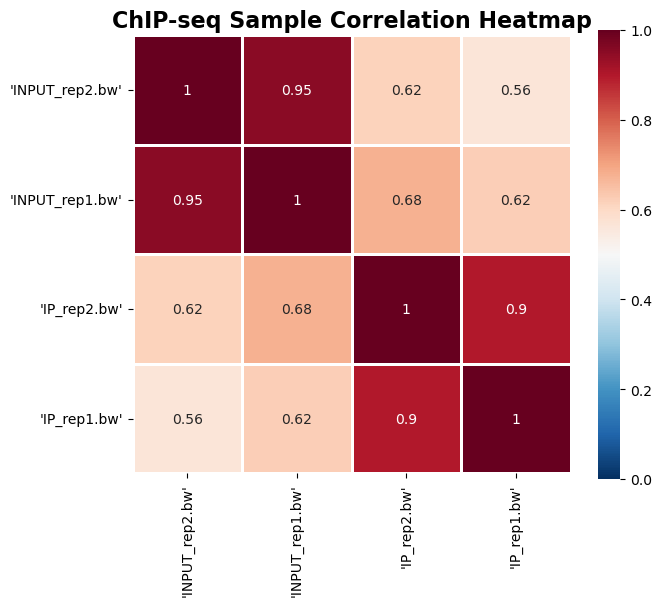

In [8]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

file_path = "/projectnb/bf528/students/shrjain/project-3-shriyajain22/results/deeptools_plotCorrelation/correlation_matrix.tab"

# ---- Read the matrix properly ----
corr = pd.read_csv(
    file_path,
    sep="\t",
    comment="#",     # skip the plotCorrelation header line
    index_col=0      # first real column is row labels
)

# Check it loaded correctly
print(corr)

# ---- Plot heatmap ----
plt.figure(figsize=(7, 6))
sns.heatmap(
    corr,
    annot=True,
    cmap="RdBu_r",
    vmin=0, vmax=1,
    square=True,
    linewidths=1,
    linecolor="white"
)

plt.title("ChIP-seq Sample Correlation Heatmap", fontsize=16, fontweight="bold")
plt.tight_layout()
plt.show()



Venn Diagram:

In [15]:
pip install matplotlib-venn

Note: you may need to restart the kernel to use updated packages.


Rep1 only: 82770
Rep2 only: 16384
Overlapping peaks: 6437


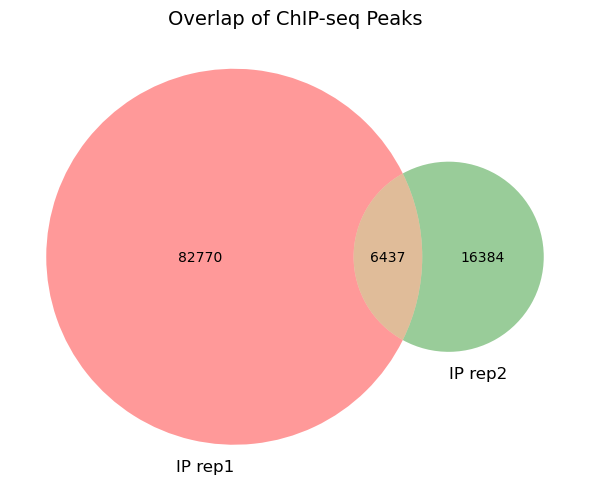

In [31]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib_venn import venn2

rep1_path = "/projectnb/bf528/students/shrjain/project-3-shriyajain22/results/pos2bed/rep1_peaks.bed"
rep2_path = "/projectnb/bf528/students/shrjain/project-3-shriyajain22/results/pos2bed/rep2_peaks.bed"

rep1 = pd.read_csv(rep1_path, sep=r"\s+", header=None, comment="#")
rep2 = pd.read_csv(rep2_path, sep=r"\s+", header=None, comment="#")

rep1 = rep1.iloc[:, :3]
rep2 = rep2.iloc[:, :3]

rep1.columns = ["chrom", "start", "end"]
rep2.columns = ["chrom", "start", "end"]

rep1 = rep1.sort_values(["chrom", "start"]).reset_index(drop=True)
rep2 = rep2.sort_values(["chrom", "start"]).reset_index(drop=True)

def count_overlaps(a, b):
    overlaps = 0
    j = 0
    b_vals = b.values

    for _, a_row in a.iterrows():
        a_chr, a_start, a_end = a_row

        while j < len(b_vals) and (b_vals[j][0] < a_chr or
                                   (b_vals[j][0] == a_chr and b_vals[j][2] < a_start)):
            j += 1

        k = j
        while k < len(b_vals) and b_vals[k][0] == a_chr and b_vals[k][1] <= a_end:
            if b_vals[k][2] >= a_start:
                overlaps += 1
                break
            k += 1
    return overlaps

n_rep1 = len(rep1)
n_rep2 = len(rep2)
n_overlap = count_overlaps(rep1, rep2)

n_rep1_only = n_rep1 - n_overlap
n_rep2_only = n_rep2 - n_overlap

print("Rep1 only:", n_rep1_only)
print("Rep2 only:", n_rep2_only)
print("Overlapping peaks:", n_overlap)

plt.figure(figsize=(6, 6))
venn2(
    subsets=(n_rep1_only, n_rep2_only, n_overlap),
    set_labels=("IP rep1", "IP rep2")
)

plt.title("Overlap of ChIP-seq Peaks", fontsize=14)
plt.tight_layout()
plt.savefig("venn_diagram.png", dpi=300)
plt.show()